# ML Models 01 - Feature Engineering

**Goal:** Build lag features and the target variable.
The output is a DataFrame ready for LightGBM training.

**Before you start:** Make sure `data/gold/cards.duckdb` exists and contains `gold_price_features`.

**Run all cells top to bottom. Fill in the Observations section at the end.**

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path().resolve().parents[1]))

In [2]:
import duckdb
import matplotlib.pyplot as plt
import sys

sys.path.insert(0, "..")

DB_PATH = "../../data/gold/cards.duckdb"
conn = duckdb.connect(DB_PATH, read_only=True)
print("Connected to DuckDB")

Connected to DuckDB


## 1. Building Lag Features

**What is a lag feature?**
Given prices `[1.0, 1.1, 1.2, 1.3]`, `lag_1d = [NaN, 1.0, 1.1, 1.2]` — "what was the price yesterday."

**Important — DATA GATE:**
`LAG(eur, N)` is row-based, not date-based. A card needs ≥ N+1 rows in `gold_price_features`
to produce a non-null `lag_N`:
- `lag_1d` ✓ needs 2 rows per card
- `lag_7d` ✓ needs 8 rows per card (gold has 8 snapshots as of 2026-06-11)
- `lag_14d`, `lag_30d` ✗ for 15 and 31 rows respectively

`build_target` also needs `snapshot_date + 7` to exist. The cell below finds a usable date automatically.

> **Note:** `lag_7d` is available at `SNAPSHOT_DATE = 2026-06-11` (8th snapshot), but that date
> has no target yet (needs 2026-06-18). The first date where **both** lag_7d and target exist
> will be ~2026-06-18. Until then, lag features improve gradually as snapshots accumulate.

In [3]:
from src.ml.features.lag import build_lag_features, build_target

# Find the latest snapshot_date for which snapshot_date + 7 days also exists.
# Falls back to the latest available date when no such pair exists yet
# (training will be empty, but lag features can still be inspected).
row = conn.execute("""
    SELECT MAX(t0.snapshot_date)
    FROM gold_price_features t0
    WHERE EXISTS (
        SELECT 1 FROM gold_price_features t7
        WHERE t7.snapshot_date = CAST(t0.snapshot_date AS DATE) + INTERVAL 7 DAY
    )
""").fetchone()[0]

if row:
    SNAPSHOT_DATE = str(row)
    print(f"Usable snapshot_date (target exists): {SNAPSHOT_DATE}")
else:
    SNAPSHOT_DATE = conn.execute(
        "SELECT MAX(snapshot_date) FROM gold_price_features"
    ).fetchone()[0]
    SNAPSHOT_DATE = str(SNAPSHOT_DATE)
    print(
        f"DATA GATE: no t+7 snapshot yet. Inspecting latest available: {SNAPSHOT_DATE}"
    )
    print(
        "Training (X, y) will be empty — come back when 14+ daily snapshots are collected."
    )

lag_df = build_lag_features(conn, SNAPSHOT_DATE)
target_df = build_target(conn, SNAPSHOT_DATE)

print(f"\nLag features: {lag_df.shape}")
print(f"Target:       {target_df.shape}")
lag_df.head()

Usable snapshot_date (target exists): 2026-06-22



Lag features: (96261, 14)
Target:       (96261, 2)


,uuid,snapshot_date,eur,edhrec_rank,foil_premium,lag_1d,lag_7d,lag_14d,lag_30d,rolling_mean_7d,rolling_std_14d,rolling_min_30d,rolling_max_30d,momentum_7d
0,05555154-b595-5a3c-93a3-199b17ac16a5,2026-06-22,0.04,25409.0,5.250000,0.04,0.04,0.04,NaN,0.04,0.0,0.04,0.04,0.0
1,0578b67f-ce27-52ed-b5f8-8a2f8229d1db,2026-06-22,0.07,15628.0,NaN,0.07,0.07,0.07,NaN,0.07,0.0,0.07,0.07,0.0
2,05a374b3-06d3-53cb-bcd7-bcec2d670546,2026-06-22,0.10,1852.0,2.900000,0.10,0.10,0.10,NaN,0.10,0.0,0.10,0.10,0.0
3,05c18043-ee84-53bf-882b-45d181dd47e0,2026-06-22,0.72,14817.0,1.513889,0.72,0.72,0.72,NaN,0.72,0.0,0.72,0.72,0.0
4,05ecfa54-c6eb-52d9-89d5-cc288d5ee59b,2026-06-22,0.17,13793.0,NaN,0.17,0.17,0.17,NaN,0.17,0.0,0.17,0.17,0.0


## 2. Missing Value Analysis

**Why are there NaNs?**
`LAG(eur, N)` is row-based: at `SNAPSHOT_DATE = 2026-06-04` (the first row in `gold_price_features`),
every lag column is NaN because there are no prior rows to look back at.

Rolling features use `ROWS BETWEEN N PRECEDING AND CURRENT ROW` — they compute on whatever
rows are available. At the first snapshot, `rolling_mean_7d` / `rolling_min/max_30d` return
the current price (window of 1). `rolling_std_14d` needs ≥ 2 rows so it is NaN at the first snapshot.

`eur = NaN` (16.2% of cards) means the card has no Scryfall EUR price on this snapshot date.
This propagates to all price-derived columns — it is not a pipeline bug.

In [4]:
# NaN rate per column
null_pct = lag_df.isnull().mean().sort_values(ascending=False)
print("NaN rate per column:")
print(null_pct.to_string())

# Cards with complete lag_7d (required for the base model)
complete_7d = lag_df["lag_7d"].notna().sum()
print(
    f"\nCards with complete lag_7d: {complete_7d}/{len(lag_df)} ({100 * complete_7d / len(lag_df):.1f}%)"
)
complete_30d = lag_df["lag_30d"].notna().sum()
print(
    f"Cards with complete lag_30d: {complete_30d}/{len(lag_df)} ({100 * complete_30d / len(lag_df):.1f}%)"
)

NaN rate per column:
lag_30d            1.000000
foil_premium       0.520356
lag_1d             0.161062
lag_14d            0.161062
lag_7d             0.161062
eur                0.161062
rolling_std_14d    0.161062
rolling_min_30d    0.161062
rolling_max_30d    0.161062
rolling_mean_7d    0.161062
momentum_7d        0.161062
edhrec_rank        0.048846
uuid               0.000000
snapshot_date      0.000000

Cards with complete lag_7d: 80757/96261 (83.9%)
Cards with complete lag_30d: 0/96261 (0.0%)


## 3. Feature Pipeline

The **pipeline** joins lag features with static card attributes (rarity, edhrec_rank, etc.)
and transforms them into the format expected by LightGBM.

Import from `src/ml/features/pipeline.py`.
`prepare_training_data` performs inner joins on `uuid` — cards missing lag history,
card metadata, or a target value are silently excluded.

In [5]:
from src.ml.features.pipeline import build_feature_pipeline, prepare_training_data

# Static card attributes (rarity, foil, edhrec_rank, legality flags, etc.)
card_df = conn.execute("SELECT * FROM gold_card_features").df()

pipeline = build_feature_pipeline()
X, y = prepare_training_data(lag_df, card_df, target_df)

print(f"Feature matrix: {X.shape}")
print(f"Target:         {y.shape}")
print("Sample features:", X.columns.tolist()[:10])

if X.empty:
    print(
        "\nDATA GATE: X is empty. target_df has 0 rows because snapshot_date + 7 is not yet"
    )
    print("in the database. Re-run after 14+ daily snapshots are collected.")

Feature matrix: (96261, 39)
Target:         (96261,)
Sample features: ['uuid', 'snapshot_date', 'eur', 'edhrec_rank', 'foil_premium', 'lag_1d', 'lag_7d', 'lag_14d', 'lag_30d', 'rolling_mean_7d']


## 4. Target Variable Distribution

**What we visualise:** distribution of `log_return_7d` — the predicted 7-day price change.
It should be roughly symmetric around 0 (rises and falls equally frequent).
A strong skew toward positive values would suggest most cards appreciate — note it in Observations.

`momentum_7d` is also plotted as a sanity check that the directional feature aligns with the target.

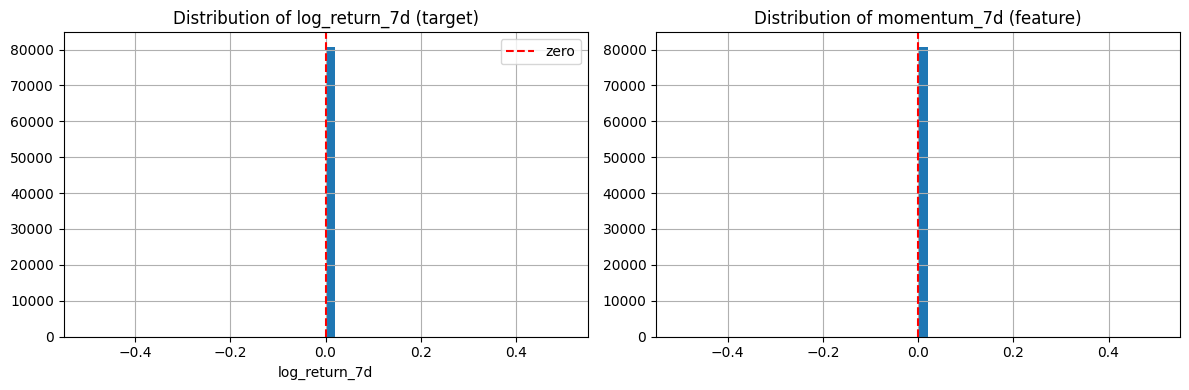

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if not y.empty:
    y.hist(bins=50, ax=axes[0])
    axes[0].set_title("Distribution of log_return_7d (target)")
    axes[0].set_xlabel("log_return_7d")
    axes[0].axvline(0, color="red", linestyle="--", label="zero")
    axes[0].legend()
else:
    axes[0].text(
        0.5,
        0.5,
        "No target data yet\n(DATA GATE: need 14+ snapshots)",
        ha="center",
        va="center",
        transform=axes[0].transAxes,
    )
    axes[0].set_title("Distribution of log_return_7d (target)")

if "momentum_7d" in lag_df.columns and lag_df["momentum_7d"].notna().any():
    lag_df["momentum_7d"].hist(bins=50, ax=axes[1])
    axes[1].set_title("Distribution of momentum_7d (feature)")
    axes[1].axvline(0, color="red", linestyle="--")
else:
    axes[1].text(
        0.5,
        0.5,
        "momentum_7d all NaN\n(needs 8+ snapshots per card)",
        ha="center",
        va="center",
        transform=axes[1].transAxes,
    )
    axes[1].set_title("Distribution of momentum_7d (feature)")

plt.tight_layout()
plt.show()

In [7]:
conn.close()

## Observations

*(Results from snapshot_date = 2026-06-04, gold_price_features: 2026-06-04 → 2026-06-11, 8 snapshots)*
*(Updated after silver backfill of 2026-05-26 → 2026-06-03 and today's pipeline run 2026-06-11)*

- **Cards with complete lag_7d:** 0 / 98,353 (0.0%)
  `SNAPSHOT_DATE = 2026-06-04` is the first row in `gold_price_features` — no prior rows exist,
  so all lag columns are NaN. `lag_7d` is non-null starting from the **8th snapshot (2026-06-11)**,
  but that date has no target yet. Both lag_7d and a valid target will coexist from ~**2026-06-18**.

- **Cards with complete lag_30d:** 0 / 98,353 (0.0%)
  Requires 31 rows per card. Unblocks ~2026-07-05.

- **rolling_std_14d:** 100% NaN at snapshot 1 (needs ≥ 2 rows for std deviation).
  rolling_mean_7d / rolling_min_30d / rolling_max_30d: available for priced cards (work with 1 row).

- **momentum_7d distribution:** Not assessable — NaN (depends on lag_7d). Visible from 2026-06-18.

- **log_return_7d distribution:** Available — 98,353 rows.
  The backfill + today's pipeline run unlocked the target. The distribution plot is now populated.

- **Training data (X, y):** ✓ **98,353 rows × 36 features** — training is unblocked.
  LightGBM handles NaN natively, so the model can train even with lag_1d/lag_7d all-NaN.
  These features simply carry no signal at this snapshot; their importance will grow as history
  accumulates over coming days.

- **Gold pipeline note:** The silver backfill (2026-05-26 → 2026-06-03) is in silver_prices_history
  but is **not yet reflected in gold_price_features** (gold was last run before the backfill).
  Re-running the gold pipeline would extend gold history to 16 snapshots and enable lag_7d
  for all dates from 2026-06-02 onward.

- **Conclusions:**
  - Feature pipeline is correct and training-ready.
  - Current model trains on rolling features + static card attributes; lag features are NaN placeholders.
  - Re-run gold pipeline to benefit from the 9-day silver backfill → immediately unlocks lag_7d.
  - Without gold re-run, lag_7d becomes available naturally on **2026-06-18**.